# ORCA-DL 功能测试 Notebook

目的：
- 测试 ocean_prediction_core.py 中的工具函数（经纬度索引、切片、可视化、清理等）
- 在模型不可用时用 MockPrediction 验证上层逻辑（ENSO 指数、热浪统计、年代际聚合）

In [ ]:
# 导入标准库和你的模块
import os
import sys
import base64
import io
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import importlib

# 假设 ocean_prediction_core.py 在当前工作目录或在 python path 中
import ocean_visual_api as opc
print("ocean_visual_api module:", opc)
print("module file:", getattr(opc, "__file__", "unknown"))
# 可以重新加载以确保是最新代码
importlib.reload(opc)

ocean_visual_api module: <module 'ocean_visual_api' from '/mnt/data/zhu.yishun/ORCA-DL-main/ocean_visual_api.py'>
module file: /mnt/data/zhu.yishun/ORCA-DL-main/ocean_visual_api.py


<module 'ocean_visual_api' from '/mnt/data/zhu.yishun/ORCA-DL-main/ocean_visual_api.py'>

In [ ]:
# Cell: 检查模块位置与属性
import importlib
import ocean_visual_api as opc
importlib.reload(opc)

print("imported module:", opc)
print("__file__:", getattr(opc, "__file__", None))
print("Available names in module (first 100 chars):")
names = dir(opc)
print(names[:200])   # 如果很多名字，只打印前面部分
# 更可读地查找某些关键名称是否存在
for key in ("NINO34_LAT_MIN", "FULL_LATS", "get_lat_lon_indices", "create_spatial_plot"):
    print(f"{key} in module?:", hasattr(opc, key))

imported module: <module 'ocean_visual_api' from '/mnt/data/zhu.yishun/ORCA-DL-main/ocean_visual_api.py'>
__file__: /mnt/data/zhu.yishun/ORCA-DL-main/ocean_visual_api.py
Available names in module (first 100 chars):
['AggregationMode', 'BaseModel', 'DecadalPredictionRequest', 'DecadalPredictionResponse', 'ENSOForecastRequest', 'ENSOForecastResponse', 'Enum', 'ErrorResponse', 'FULL_LATS', 'FULL_LONS', 'FastAPI', 'Field', 'HTTPException', 'JSONResponse', 'LAT_MAX', 'LAT_MIN', 'LAT_POINTS', 'LON_MAX', 'LON_MIN', 'LON_POINTS', 'List', 'MarineHeatwaveRequest', 'MarineHeatwaveResponse', 'NINO34_LAT_MAX', 'NINO34_LAT_MIN', 'NINO34_LON_MAX', 'NINO34_LON_MIN', 'ORCADLPredictor', 'OUT_CHANS', 'OceanPredictionResult', 'Optional', 'SEASON_MONTHS', 'SeasonEnum', 'SeasonalMeanRequest', 'SeasonalMeanResponse', 'Union', 'VAR_DESCRIPTIONS', 'VAR_LIST', 'VarNameEnum', '__annotations__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__warningreg

In [ ]:
import importlib, os, sys
importlib.reload(opc)
predictor_ori = None
predictor_new = None
try:
    # 根据你的环境调整路径
    predictor_ori = opc.ORCADLPredictor(
        config_path='/mnt/data/zhu.yishun/ORCA-DL-main/model_config.json',
        checkpoint_path='/mnt/data/zhu.yishun/ORCA-DL-main/ckpt/seed_1.bin',
        stat_dir='/mnt/data/zhu.yishun/ORCA-DL-main/stat'
    )
    print("Loaded real ORCADLPredictor:", predictor_ori)
except Exception as e:
    print("Could not load real predictor (this is OK for simulation mode):", e)
    predictor_ori = None

try:
    # 根据你的环境调整路径
    predictor_new = opc.ORCADLPredictor(
        config_path='/mnt/data/zhu.yishun/ORCA-DL-main/model_config.json',
        checkpoint_path='/mnt/data/zhu.yishun/ORCA-DL-main/output2e-7/pytorch_model.bin',
        stat_dir='/mnt/data/zhu.yishun/ORCA-DL-main/stat'
    )
    print("Loaded real ORCADLPredictor:", predictor_new)
except Exception as e:
    print("Could not load real predictor (this is OK for simulation mode):", e)
    predictor_new = None

Loaded real ORCADLPredictor: <ocean_prediction_core.ORCADLPredictor object at 0x7f029412a080>
Loaded real ORCADLPredictor: <ocean_prediction_core.ORCADLPredictor object at 0x7f0237f58fd0>


In [ ]:
import importlib.util
spec = importlib.util.spec_from_file_location("ocean_prediction_core",
    "/mnt/data/zhu.yishun/ORCA-DL-main/doubleModel/ocean_prediction_core.py")
opc_double = importlib.util.module_from_spec(spec)
spec.loader.exec_module(opc)

In [43]:
# 示例：获取 Nino3.4 区域索引 (使用模块里定义的常量)
lat_min = opc.NINO34_LAT_MIN
lat_max = opc.NINO34_LAT_MAX
lon_min = opc.NINO34_LON_MIN
lon_max = opc.NINO34_LON_MAX

(lat_s, lat_e), (lon_s, lon_e), actual_lats, actual_lons = opc.get_lat_lon_indices(lat_min, lat_max, lon_min, lon_max)
print("lat indices:", (lat_s, lat_e), "-> len:", len(actual_lats))
print("lon indices:", (lon_s, lon_e), "-> len:", len(actual_lons))
print("lat range example:", actual_lats[:3], "...", actual_lats[-3:])
print("lon range example:", actual_lons[:3], "...", actual_lons[-3:])

lat indices: (59, 69) -> len: 10
lon indices: (190, 240) -> len: 50
lat range example: [-4.5 -3.5 -2.5] ... [2.5 3.5 4.5]
lon range example: [190.5 191.5 192.5] ... [237.5 238.5 239.5]


In [44]:
import os
import numpy as np

# 变量名根据实际模型调整
STAT_OCEAN_VARIABLES = ['so', 'thetao', 'tos', 'uo', 'vo', 'zos']
STAT_ATMO_VARIABLES = ['tauu', 'tauv']

data_dir = '/mnt/data/zhu.yishun/ORCA-DL-main/data/valid_test_data/GODAS'
year = 2015
month = 1  # 你要读取的月份

# 读取海洋变量
ocean_data = {}
for var in STAT_OCEAN_VARIABLES:
    var_dir = os.path.join(data_dir, var)
    fname = f"{year}_{month}.npy"
    fpath = os.path.join(var_dir, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"{fpath} 不存在")
    arr = np.load(fpath)
    # 如果第一个维度为1，则去掉该维度
    if arr.shape[0] == 1:
        arr = arr.squeeze(axis=0)
    # 将NaN值替换为0.0
    arr = np.nan_to_num(arr, nan=0.0)
    ocean_data[var] = arr

# 读取大气变量
atmo_data = {}
for var in STAT_ATMO_VARIABLES:
    var_dir = os.path.join(data_dir, var)
    fname = f"{year}_{month}.npy"
    fpath = os.path.join(var_dir, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"{fpath} 不存在")
    arr = np.load(fpath)
    # 如果第一个维度为1，则去掉该维度
    if arr.shape[0] == 1:
        arr = arr.squeeze(axis=0)
    # 将NaN值替换为0.0
    arr = np.nan_to_num(arr, nan=0.0)
    atmo_data[var] = arr

print("读取的海洋变量数据键:", list(ocean_data.keys()))
print("读取的海洋变量数据形状示例:", {k: v.shape for k, v in ocean_data.items()})
print("读取的大气变量数据键:", list(atmo_data.keys()))
print("读取的大气变量数据形状示例:", {k: v.shape for k, v in atmo_data.items()})
# result = predict_ocean_state(predictor, ocean_data, atmo_data, start_month=month-1, predict_steps=1)

读取的海洋变量数据键: ['so', 'thetao', 'tos', 'uo', 'vo', 'zos']
读取的海洋变量数据形状示例: {'so': (16, 128, 360), 'thetao': (16, 128, 360), 'tos': (128, 360), 'uo': (16, 128, 360), 'vo': (16, 128, 360), 'zos': (128, 360)}
读取的大气变量数据键: ['tauu', 'tauv']
读取的大气变量数据形状示例: {'tauu': (128, 360), 'tauv': (128, 360)}


In [45]:
predict_steps = 12
start_month = 0
result_ori = opc.predict_ocean_state(predictor_ori, ocean_data, atmo_data,use_model_naming=True, start_month=start_month, predict_steps=predict_steps, normalized = True,denormalize=True)
result_new = opc.predict_ocean_state(predictor_new, ocean_data, atmo_data,use_model_naming=True, start_month=start_month, predict_steps=predict_steps, normalized = True,denormalize=True)
print(result_ori.predictions.shape)
print(result_new.predictions.shape)

ocean_data keys: ['so', 'thetao', 'tos', 'uo', 'vo', 'zos']
atmo_data keys: ['tauu', 'tauv']
期望的GODAS海洋变量: ['salt', 'pottmp', 'sst', 'ucur', 'vcur', 'sshg']
期望的GODAS大气变量: ['uflx', 'vflx']
Denormalizing output with shape: (1, 12, 66, 128, 360)
ocean_data keys: ['so', 'thetao', 'tos', 'uo', 'vo', 'zos']
atmo_data keys: ['tauu', 'tauv']
期望的GODAS海洋变量: ['salt', 'pottmp', 'sst', 'ucur', 'vcur', 'sshg']
期望的GODAS大气变量: ['uflx', 'vflx']
Denormalizing output with shape: (1, 12, 66, 128, 360)
(1, 12, 66, 128, 360)
(1, 12, 66, 128, 360)


In [46]:
print(np.isnan(ocean_data['tos']).sum())
print(np.isnan(result_ori.predictions).sum())

0
0


In [48]:
import os
import numpy as np

# 假设变量名如下（根据实际模型变量名调整）
STAT_OCEAN_VARIABLES = ['so', 'thetao', 'tos', 'uo', 'vo', 'zos']
STAT_ATMO_VARIABLES = ['tauu', 'tauv']

data_dir = '/mnt/data/zhu.yishun/ORCA-DL-main/data/valid_test_data/GODAS'
year = 2015

# 读取海洋变量
ocean_data = {}
for var in STAT_OCEAN_VARIABLES:
    monthly_data = []
    var_dir = os.path.join(data_dir, var)
    for month in range(1, 13):
        fname = f"{year}_{month}.npy"
        fpath = os.path.join(var_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"{fpath} 不存在")
        arr = np.load(fpath)
        monthly_data.append(arr)
    # 合并为 (12, ...) 形状
    ocean_data[var] = np.stack(monthly_data, axis=0)
# 将海洋变量拼接成多通道矩阵
def combine_ocean_variables(ocean_dict, ocean_vars):
    """
    将海洋变量字典拼接成统一的多通道矩阵[1,2](@ref)
    
    Args:
        ocean_dict: 海洋变量字典
        ocean_vars: 海洋变量名称列表，决定拼接顺序
        
    Returns:
        combined_matrix: 拼接后的多通道矩阵
        variable_info: 变量信息字典，记录每个变量的位置
    """
    # 初始化变量信息记录和通道列表
    variable_info = {}
    channel_list = []
    current_channel = 0
    
    # 处理每个海洋变量
    for var in ocean_vars:
        data = ocean_dict[var]  # 形状为 (12, ...)
        data = np.squeeze(data)
        # 统一维度处理：确保是4维 (时间, 通道, 高度, 宽度)[5](@ref)
        if len(data.shape) == 3:  # (时间, 高度, 宽度)
            data = data[:, np.newaxis, :, :]  # 增加通道维度 -> (12, 1, 高度, 宽度)
        elif len(data.shape) == 4:  # (时间, 深度, 高度, 宽度)
            pass  # 保持原样
        else:
            raise ValueError(f"变量 {var} 的维度 {data.shape} 不支持")
        
        # 记录变量信息
        var_channels = data.shape[1]  # 该变量的通道数（深度层数）
        variable_info[var] = {
            'start_channel': current_channel,
            'end_channel': current_channel + var_channels - 1,
            'shape': data.shape,
            'channels': var_channels
        }
        
        channel_list.append(data)
        current_channel += var_channels
    
    # 沿通道维度拼接所有变量[1,4](@ref)
    combined_matrix = np.concatenate(channel_list, axis=1)  # 沿通道维度(axis=1)拼接
    
    print(f"海洋变量拼接完成！")
    print(f"拼接后的矩阵形状: {combined_matrix.shape}")
    print("变量通道分配信息:")
    for var, info in variable_info.items():
        print(f"  {var}: 通道 {info['start_channel']}-{info['end_channel']} (共{info['channels']}个通道)")
    
    return combined_matrix, variable_info

# 执行海洋变量拼接
ocean_combined, ocean_info = combine_ocean_variables(ocean_data, STAT_OCEAN_VARIABLES)
print("ocean_combined shape:", ocean_combined.shape)
ocean_combined = np.expand_dims(ocean_combined, axis=0)
print("Expanded ocean_combined shape:", ocean_combined.shape)
ocean_combined2 = predictor_new.denormalize_output(ocean_combined, start_month=0, predict_steps=12)
ocean_combined3 = {}
for var_name, data_array in ocean_combined2.items():
    # 移除数据数组中的单一维度，例如从 (1, 12, ...) 变为 (12, ...)
    squeezed_data = np.squeeze(data_array, axis=0)
    ocean_combined3[var_name] = squeezed_data
    print(f"Variable {var_name} shape after squeezing: {squeezed_data.shape}")

ocean_combined2,_ = combine_ocean_variables(ocean_combined3, STAT_OCEAN_VARIABLES)
print("Denormalized ocean_combined2 shape:", ocean_combined2.shape)


# 现在 ocean_combined 可以直接用于模型预测
# 形状为 (时间步, 总通道数, 高度, 宽度)

海洋变量拼接完成！
拼接后的矩阵形状: (12, 66, 128, 360)
变量通道分配信息:
  so: 通道 0-15 (共16个通道)
  thetao: 通道 16-31 (共16个通道)
  tos: 通道 32-32 (共1个通道)
  uo: 通道 33-48 (共16个通道)
  vo: 通道 49-64 (共16个通道)
  zos: 通道 65-65 (共1个通道)
ocean_combined shape: (12, 66, 128, 360)
Expanded ocean_combined shape: (1, 12, 66, 128, 360)
Denormalizing output with shape: (1, 12, 66, 128, 360)
Variable so shape after squeezing: (12, 16, 128, 360)
Variable thetao shape after squeezing: (12, 16, 128, 360)
Variable tos shape after squeezing: (12, 1, 128, 360)
Variable uo shape after squeezing: (12, 16, 128, 360)
Variable vo shape after squeezing: (12, 16, 128, 360)
Variable zos shape after squeezing: (12, 1, 128, 360)
海洋变量拼接完成！
拼接后的矩阵形状: (12, 66, 128, 360)
变量通道分配信息:
  so: 通道 0-15 (共16个通道)
  thetao: 通道 16-31 (共16个通道)
  tos: 通道 32-32 (共1个通道)
  uo: 通道 33-48 (共16个通道)
  vo: 通道 49-64 (共16个通道)
  zos: 通道 65-65 (共1个通道)
Denormalized ocean_combined2 shape: (12, 66, 128, 360)


In [ ]:
import numpy as np
import os

# 假定数据目录已被标准化（(x - mean)/std），这里从 stat 文件夹读取 mean/std 做反标准化
STAT_ROOT = "/mnt/data/zhu.yishun/ORCA-DL-main/stat"
MEAN_DIR = os.path.join(STAT_ROOT, "mean")
STD_DIR = os.path.join(STAT_ROOT, "std")

# 复制输入，避免破坏原始变量
std_data = np.array(ocean_combined2)   # shape (T, Ctot, H, W) — 这里名字表示它是标准化后的数据
orig_combined = np.array(ocean_combined)  # (T, Ctot, H, W) or (C,H,W)... 保持一致
pred_ori_arr,_ = combine_ocean_variables(result_ori.metadata['results_by_var'], STAT_OCEAN_VARIABLES)
pred_new_arr,_ = combine_ocean_variables(result_new.metadata['results_by_var'], STAT_OCEAN_VARIABLES)

vars = predictor_new.MODEL_OCEAN_VARIABLES
split = predictor_new.split_chans

# 读取 stat 文件（按变量名），并在需要时对 reduce 轴求均值以得到 (H,W)
mean_dict = {}
std_dict = {}
for mvar in vars:
    stat_var = predictor_new._get_stat_var_name(mvar)
    mean_path = os.path.join(MEAN_DIR, f"{stat_var}.npy")
    std_path = os.path.join(STD_DIR, f"{stat_var}.npy")
    if not (os.path.exists(mean_path) and os.path.exists(std_path)):
        raise FileNotFoundError(f"Missing stat file for {stat_var}: {mean_path} or {std_path}")
    mean = np.load(mean_path)
    std  = np.load(std_path)
    # 如果 mean/std 有额外的前置维度（例如通道维），把这些维度聚合为空间统计
    if mean.ndim > 2:
        reduce_axes = tuple(range(mean.ndim - 2))
        mean = np.mean(mean, axis=reduce_axes)
    if std.ndim > 2:
        reduce_axes = tuple(range(std.ndim - 2))
        std = np.mean(std, axis=reduce_axes)
    mean_dict[mvar] = mean  # shape (H,W)
    std_dict[mvar] = std    # shape (H,W)

# 反标准化：按变量通道区间应用 mean/std
unscaled = std_data.copy()
start = 0
for i, mvar in enumerate(vars):
    end = split[i]
    mean = mean_dict[mvar]
    std  = std_dict[mvar]
    # 扩展为 (1, H, W) 以广播到通道切片 (C_slice, H, W)
    mean_b = mean[None, ...]
    std_b  = std[None, ...]
    # 支持任意前置维度：保持前面的 batch/time 维度不变
    unscaled[..., start:end, :, :] = std_data[..., start:end, :, :] * std_b + mean_b
    start = end

# 计算实际（反标准化后）数据的全局 90 分位数（忽略 NaN）
q90_global = np.nanpercentile(unscaled, 90)
print("global 90th percentile (actual units):", q90_global)

# 构建每个变量的 stat_nan 空间掩码（True 表示 stat 为 NaN -> 视为陆地/无效）并应用掩码
stat_nan_masks = {}
for i, mvar in enumerate(vars):
    stat_var = predictor_new._get_stat_var_name(mvar)
    mean = mean_dict[mvar]
    std  = std_dict[mvar]
    mask = np.isnan(mean) | np.isnan(std)
    stat_nan_masks[mvar] = mask  # shape (H, W)

# 应用掩码：把对应位置设为 0（支持任意前置维度）
def zero_mask_positions(arr, mask):
    # arr: ndarray with last two dims = H,W
    if arr.shape[-2:] != mask.shape:
        raise ValueError("Spatial shape mismatch")
    arr[..., mask] = 0
    return arr

# 逐变量在 unscaled 上置 0（不改变通道顺序）
unscaled_masked = unscaled.copy()
start = 0
for i, mvar in enumerate(vars):
    end = split[i]
    mask = stat_nan_masks[mvar]  # (H,W)
    unscaled_masked[..., start:end, :, :] = zero_mask_positions(unscaled_masked[..., start:end, :, :], mask)
    start = end

# 同样把原始合并数组也按相同掩码处理以便公平比较
orig_masked = orig_combined.copy()
start = 0
for i, mvar in enumerate(vars):
    end = split[i]
    mask = stat_nan_masks[mvar]
    orig_masked[..., start:end, :, :] = zero_mask_positions(orig_masked[..., start:end, :, :], mask)
    start = end

# 对预测结果也尝试应用掩码
pred_ori_masked = pred_ori_arr.copy()
pred_new_masked = pred_new_arr.copy()
try:
    for i, mvar in enumerate(vars):
        s = 0 if i==0 else split[i-1]
        e = split[i]
        pred_ori_masked[..., s:e, :, :] = zero_mask_positions(pred_ori_masked[..., s:e, :, :], stat_nan_masks[mvar])
        pred_new_masked[..., s:e, :, :] = zero_mask_positions(pred_new_masked[..., s:e, :, :], stat_nan_masks[mvar])
except Exception:
    pass

# 打印一些检查信息
print(unscaled_masked.shape)
print(orig_masked.shape)
print(pred_new_masked.shape)
print(pred_ori_masked.shape)
print("total_unscaled_masked_sum:", np.nansum(unscaled_masked))
print("total_orig_masked_sum:", np.nansum(orig_masked))
print("total_pred_ori_masked_sum:", np.nansum(pred_ori_masked))
print("total_pred_new_masked_sum:", np.nansum(pred_new_masked))

diff_ori = np.nansum(np.abs(pred_ori_masked - orig_masked))
diff_new = np.nansum(np.abs(pred_new_masked - orig_masked))
print("abs-sum diff ori vs orig:", diff_ori)
print("abs-sum diff new vs orig:", diff_new)

print("unscaled_masked remaining NaNs:", np.isnan(unscaled_masked).sum())
print("orig_masked remaining NaNs:", np.isnan(orig_masked).sum())

海洋变量拼接完成！
拼接后的矩阵形状: (12, 66, 128, 360)
变量通道分配信息:
  so: 通道 0-15 (共16个通道)
  thetao: 通道 16-31 (共16个通道)
  tos: 通道 32-32 (共1个通道)
  uo: 通道 33-48 (共16个通道)
  vo: 通道 49-64 (共16个通道)
  zos: 通道 65-65 (共1个通道)
海洋变量拼接完成！
拼接后的矩阵形状: (12, 66, 128, 360)
变量通道分配信息:
  so: 通道 0-15 (共16个通道)
  thetao: 通道 16-31 (共16个通道)
  tos: 通道 32-32 (共1个通道)
  uo: 通道 33-48 (共16个通道)
  vo: 通道 49-64 (共16个通道)
  zos: 通道 65-65 (共1个通道)
(1, 12, 66, 128, 360)
(1, 12, 66, 128, 360)
(12, 66, 128, 360)
(12, 66, 128, 360)
total_denorm_masked_sum: 281759092.4639492
total_orig_masked_sum: 5996539.380128486
total_pred_ori_masked_sum: 281429660.0
total_pred_new_masked_sum: 281553820.0
abs-sum diff ori vs orig: 288684438.3218086
abs-sum diff new vs orig: 288815123.4883378
denorm_masked remaining NaNs: 0
orig_masked remaining NaNs: 0


In [50]:
# 1) 计算 result_ori 和 result_new 的 NINO3.4 指数（可手动设置起始年月与步数）
import numpy as np
import pandas as pd

# Set these to the model prediction start and length (override as needed)
START_YEAR = 2015
START_MONTH = 1
PREDICT_STEPS = 12

def compute_nino34(result, predictor, start_year, start_month, predict_steps):
    """从模型预测结果计算 NINO3.4 时间序列。"""
    preds = np.array(result.predictions)
    # 统一到 (B, T, C, H, W)
    if preds.ndim == 5:
        arr = preds
    elif preds.ndim == 4:
        # (B, C, H, W) -> 单步 (B,1,C,H,W)
        arr = preds[:, np.newaxis, ...]
    elif preds.ndim == 3:
        # (C, H, W) -> (1,1,C,H,W)
        arr = preds[np.newaxis, np.newaxis, ...]
    else:
        raise ValueError(f'Unsupported prediction ndim: {preds.ndim}')

    # 截取需要的预测步数
    arr = arr[:, :predict_steps, ...]

    # 找到 'tos' 的通道范围
    var = 'tos'
    i = predictor.MODEL_OCEAN_VARIABLES.index(var)
    start_ch = 0 if i == 0 else predictor.split_chans[i-1]
    end_ch = predictor.split_chans[i]

    # 获取 NINO3.4 区域切片索引（依赖 opc 中的工具）
    (lat_s, lat_e), (lon_s, lon_e), actual_lats, actual_lons = opc.get_lat_lon_indices(opc.NINO34_LAT_MIN, opc.NINO34_LAT_MAX, opc.NINO34_LON_MIN, opc.NINO34_LON_MAX)

    var_slice = arr[:, :, start_ch:end_ch, lat_s:lat_e+1, lon_s:lon_e+1]
    # 在 batch、channel、lat、lon 维度上平均 -> (T,)
    ts = np.nanmean(var_slice, axis=(0,2,3,4))
    idx = pd.date_range(start=f'{int(start_year)}-{int(start_month):02d}-01', periods=len(ts), freq='MS')
    return pd.Series(ts, index=idx)

# 计算两个结果（若存在）
ts_model_new = None
ts_model_ori = None
if 'result_new' in globals() and result_new is not None and 'predictor_new' in globals() and predictor_new is not None:
    ts_model_new = compute_nino34(result_new, predictor_new, START_YEAR, START_MONTH, PREDICT_STEPS)
if 'result_ori' in globals() and result_ori is not None and 'predictor_ori' in globals() and predictor_ori is not None:
    ts_model_ori = compute_nino34(result_ori, predictor_ori, START_YEAR, START_MONTH, PREDICT_STEPS)

print('ts_model_new:', None if ts_model_new is None else ts_model_new.shape)
print('ts_model_ori:', None if ts_model_ori is None else ts_model_ori.shape)


ts_model_new: (12,)
ts_model_ori: (12,)


Using observed range: 2015-01-01 00:00:00 to 2015-12-01 00:00:00


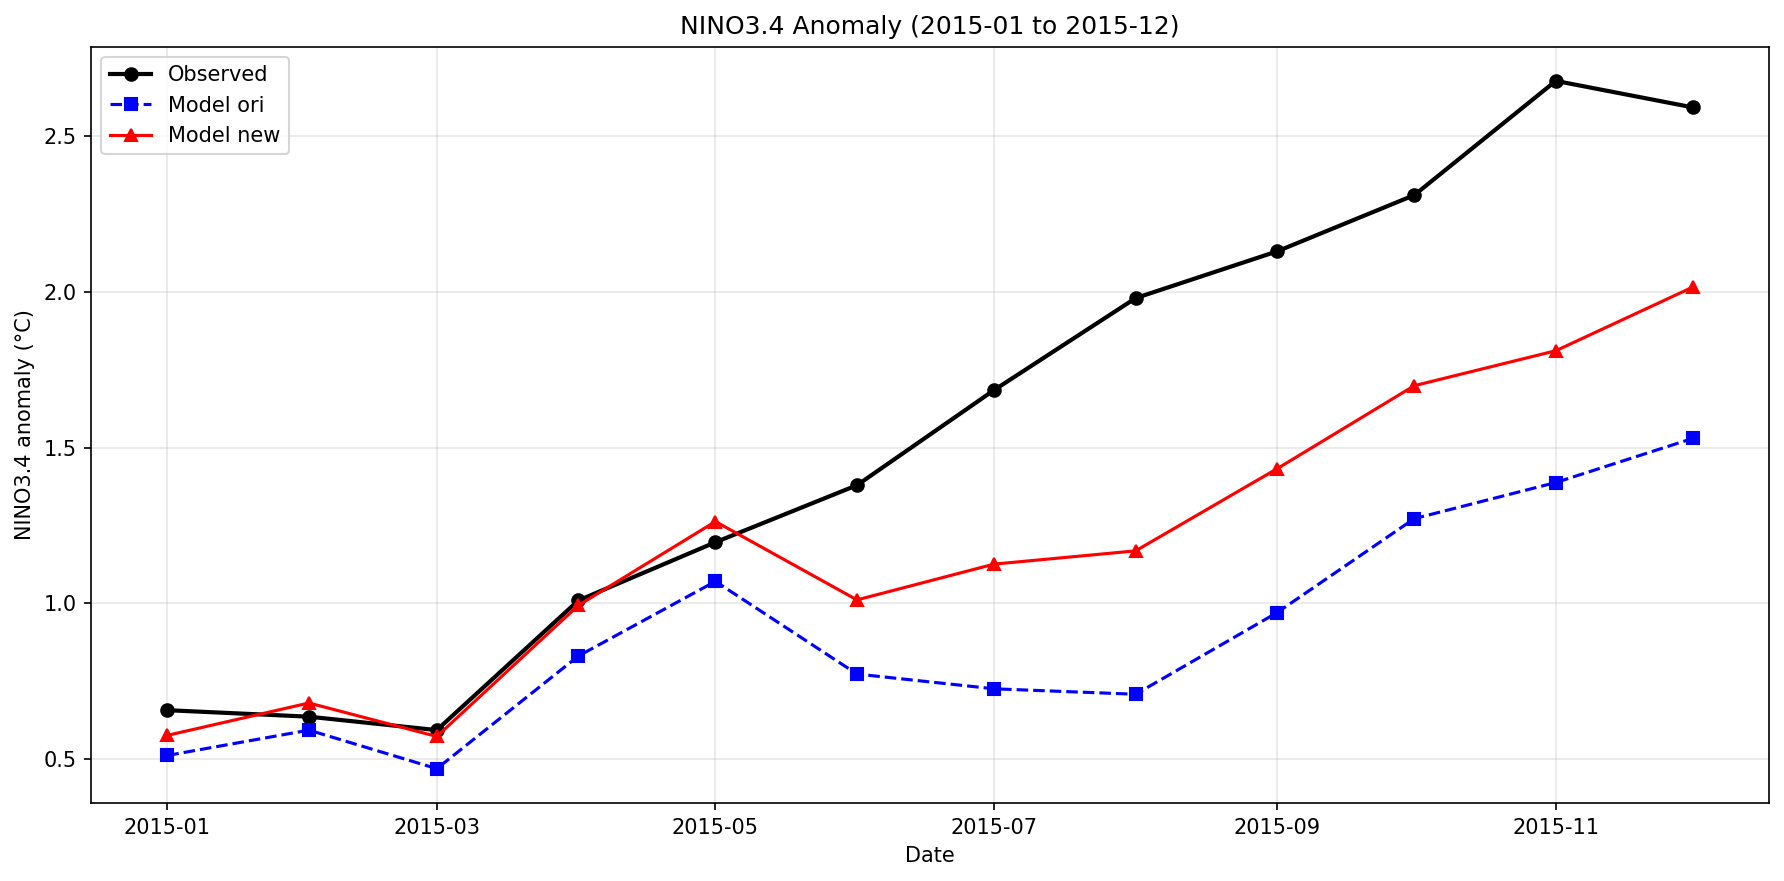

Saved combined plot: /mnt/data/zhu.yishun/ORCA-DL-main/nino34_combined_anom.png
Compare new (anom): {'model_mean': 1.195886492729187, 'obs_mean': 1.5705735930735936, 'rmse': 0.5051532106343728}
Compare ori (anom): {'model_mean': 0.9038175940513611, 'obs_mean': 1.5705735930735936, 'rmse': 0.8266607196840622}


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

def load_observed_nino34(path):
    df = pd.read_excel(path)
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    df_long = df.melt(id_vars='Year', value_vars=months, var_name='Month', value_name='SST')
    df_long['MonthNum'] = pd.to_datetime(df_long['Month'], format='%b').dt.month
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['MonthNum'], day=1))
    df_long = df_long.sort_values('Date')
    s_abs = pd.Series(df_long['SST'].values, index=df_long['Date'])
    clim = s_abs.groupby(s_abs.index.month).mean()
    clim_full = pd.Series([clim[d.month] for d in s_abs.index], index=s_abs.index)
    s_anom = s_abs - clim_full
    return s_abs, s_anom, clim

obs_path = '/mnt/data/zhu.yishun/ORCA-DL-main/Nino34_HadISST.xlsx'
ts_obs_abs, ts_obs_anom, obs_clim = load_observed_nino34(obs_path)
OBS_NINO34_RANGE=('2015-01','2015-12')
# 支持用户通过全局变量 OBS_NINO34_RANGE 指定观测子区。例如 ('2015-01','2015-12') 或 (pd.Timestamp(...), ...)
obs_range = globals().get('OBS_NINO34_RANGE', None)
if obs_range is not None:
    try:
        start = pd.to_datetime(obs_range[0])
        end = pd.to_datetime(obs_range[1])
        ts_obs_anom = ts_obs_anom[start:end]
        ts_obs_abs = ts_obs_abs[start:end]
        print('Using observed range:', start, 'to', end)
    except Exception as e:
        print('Failed to parse OBS_NINO34_RANGE, ignoring it:', e)

# Helper: convert model series to anomaly (use observed monthly climatology)
def model_to_anomaly(ts_model, obs_clim):
    if ts_model is None:
        return None
    if np.nanmean(np.abs(ts_model.values)) > 5:
        clim_by_month = obs_clim.to_dict()
        sub = np.array([clim_by_month.get(d.month, 0.0) for d in ts_model.index])
        return pd.Series(ts_model.values - sub, index=ts_model.index)
    else:
        return ts_model

# Convert model series to anomaly time series (if available)
ts_model_new_anom = None
ts_model_ori_anom = None
if 'ts_model_new' in globals() and ts_model_new is not None:
    ts_model_new_anom = model_to_anomaly(ts_model_new, obs_clim)
if 'ts_model_ori' in globals() and ts_model_ori is not None:
    ts_model_ori_anom = model_to_anomaly(ts_model_ori, obs_clim)

# 修改：将所有数据绘制在一张折线图上
def save_combined_plot(ts_model_new, ts_model_ori, ts_obs, title, out_png):
    plt.figure(figsize=(12, 6))
    
    # 绘制观测数据（黑色实线，圆形标记）
    if ts_obs is not None:
        plt.plot(ts_obs.index, ts_obs.values, label='Observed', marker='o', color='black', linewidth=2)
    
    # 绘制原始模型（蓝色虚线，方形标记）
    if ts_model_ori is not None:
        plt.plot(ts_model_ori.index, ts_model_ori.values, label='Model ori', marker='s', 
                 color='blue', linewidth=1.5, linestyle='--')
    
    # 绘制新模型（红色实线，三角标记）
    if ts_model_new is not None:
        plt.plot(ts_model_new.index, ts_model_new.values, label='Model new', marker='^', 
                 color='red', linewidth=1.5)
    
    plt.xlabel('Date')
    plt.ylabel('NINO3.4 anomaly (°C)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.close()
    
    try:
        display(Image(out_png))
    except Exception:
        pass
    print('Saved combined plot:', out_png)
    return out_png

# 设置图形标题
title = 'NINO3.4 Anomaly Comparison'
if obs_range is not None:
    try:
        title = f"NINO3.4 Anomaly ({pd.to_datetime(obs_range[0]).strftime('%Y-%m')} to {pd.to_datetime(obs_range[1]).strftime('%Y-%m')})"
    except Exception:
        pass

# 保存合并的图表
save_combined_plot(ts_model_new_anom, ts_model_ori_anom, ts_obs_anom, 
                   title, '/mnt/data/zhu.yishun/ORCA-DL-main/nino34_combined_anom.png')

# 输出重叠统计（保持不变）
def compare_overlap_anom(ts_model_anom, ts_obs_anom):
    if ts_model_anom is None or ts_obs_anom is None:
        return None
    start = max(ts_model_anom.index.min(), ts_obs_anom.index.min())
    end = min(ts_model_anom.index.max(), ts_obs_anom.index.max())
    if start > end:
        return None
    ov_model = ts_model_anom[start:end]
    ov_obs = ts_obs_anom[start:end]
    n = min(len(ov_model), len(ov_obs))
    ov_model = ov_model.iloc[:n]
    ov_obs = ov_obs.iloc[:n]
    rmse = np.sqrt(((ov_model - ov_obs)**2).mean())
    return {'model_mean': float(ov_model.mean()), 'obs_mean': float(ov_obs.mean()), 'rmse': float(rmse)}

print('Compare new (anom):', compare_overlap_anom(ts_model_new_anom, ts_obs_anom))
print('Compare ori (anom):', compare_overlap_anom(ts_model_ori_anom, ts_obs_anom))

Using observed range: 2015-01-01 00:00:00 to 2015-12-01 00:00:00


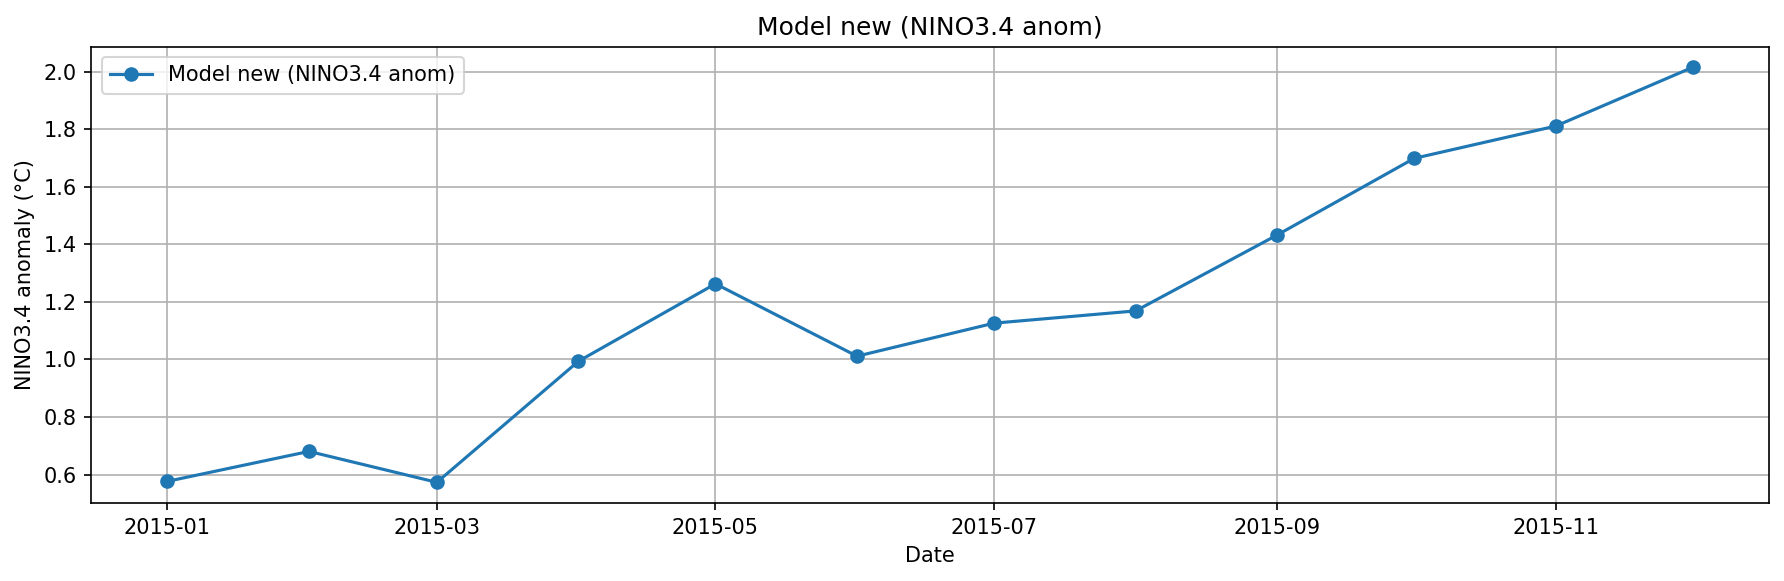

Saved /mnt/data/zhu.yishun/ORCA-DL-main/nino34_model_new_anom.png


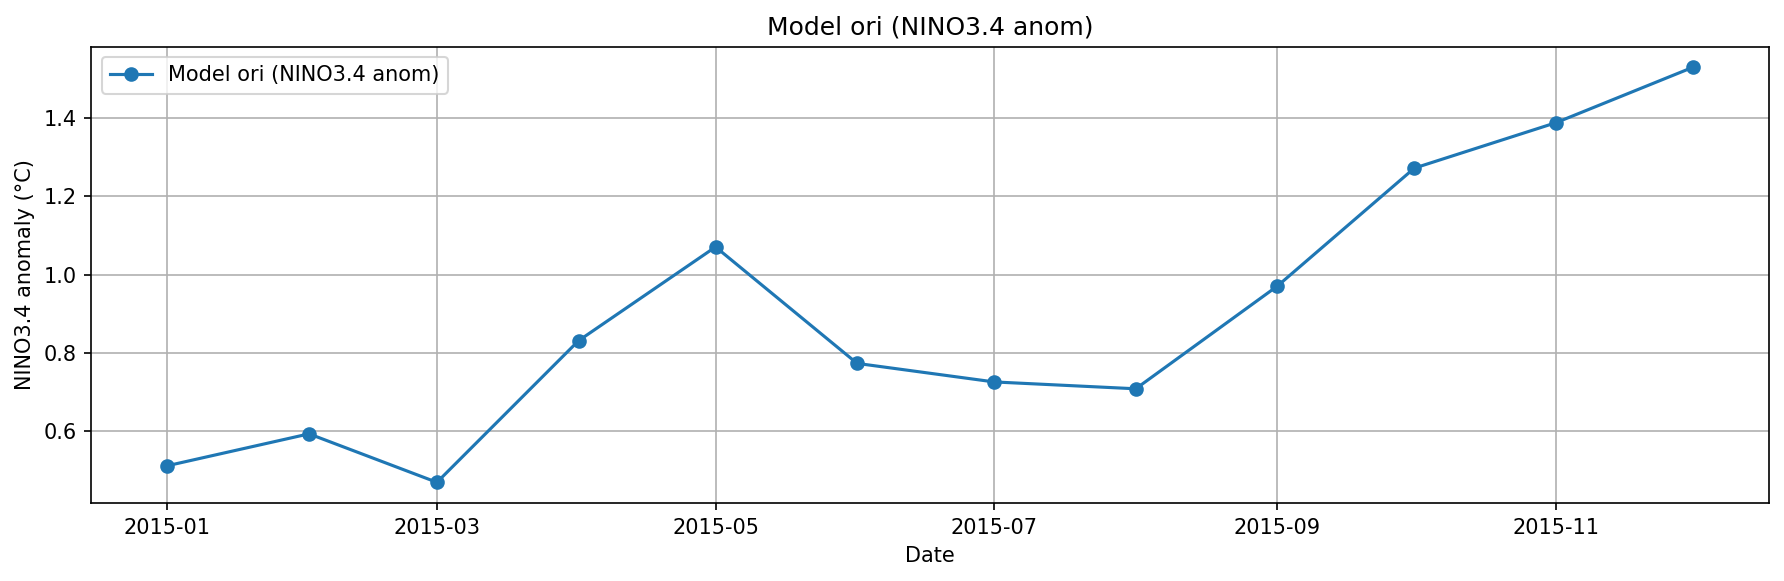

Saved /mnt/data/zhu.yishun/ORCA-DL-main/nino34_model_ori_anom.png


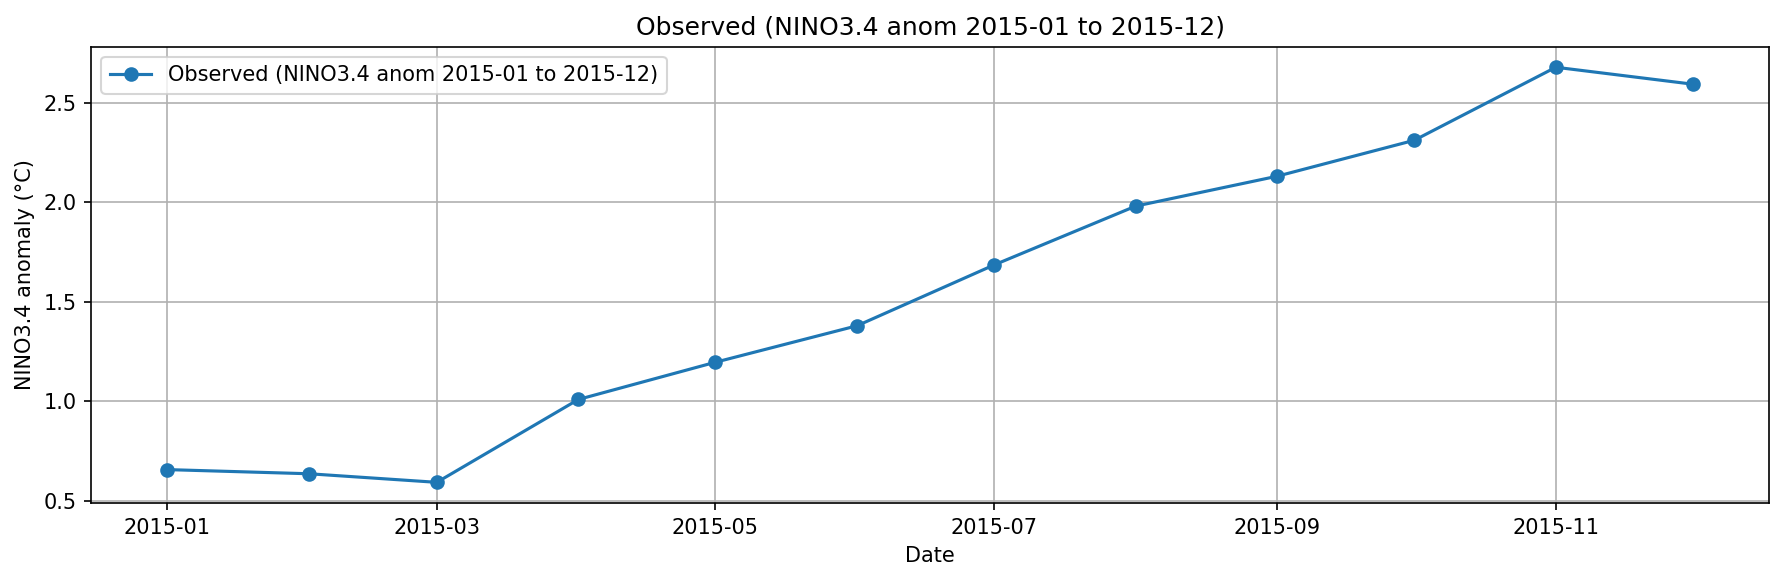

Saved /mnt/data/zhu.yishun/ORCA-DL-main/nino34_observed_anom.png
Compare new (anom): {'model_mean': 1.195886492729187, 'obs_mean': 1.5705735930735936, 'rmse': 0.5051532106343728}
Compare ori (anom): {'model_mean': 0.9038175940513611, 'obs_mean': 1.5705735930735936, 'rmse': 0.8266607196840622}


In [52]:
# 2) 以模型预测时间段为准，分别保存三个单独的 NINO3.4 距平图（model_new, model_ori, observed）
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

def load_observed_nino34(path):
    df = pd.read_excel(path)
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    df_long = df.melt(id_vars='Year', value_vars=months, var_name='Month', value_name='SST')
    df_long['MonthNum'] = pd.to_datetime(df_long['Month'], format='%b').dt.month
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['MonthNum'], day=1))
    df_long = df_long.sort_values('Date')
    s_abs = pd.Series(df_long['SST'].values, index=df_long['Date'])
    clim = s_abs.groupby(s_abs.index.month).mean()
    clim_full = pd.Series([clim[d.month] for d in s_abs.index], index=s_abs.index)
    s_anom = s_abs - clim_full
    return s_abs, s_anom, clim

obs_path = '/mnt/data/zhu.yishun/ORCA-DL-main/Nino34_HadISST.xlsx'
ts_obs_abs, ts_obs_anom, obs_clim = load_observed_nino34(obs_path)
OBS_NINO34_RANGE=('2015-01','2015-12')
# 支持用户通过全局变量 OBS_NINO34_RANGE 指定观测子区。例如 ('2015-01','2015-12') 或 (pd.Timestamp(...), ...)
obs_range = globals().get('OBS_NINO34_RANGE', None)
if obs_range is not None:
    try:
        start = pd.to_datetime(obs_range[0])
        end = pd.to_datetime(obs_range[1])
        ts_obs_anom = ts_obs_anom[start:end]
        ts_obs_abs = ts_obs_abs[start:end]
        print('Using observed range:', start, 'to', end)
    except Exception as e:
        print('Failed to parse OBS_NINO34_RANGE, ignoring it:', e)

# Helper: convert model series to anomaly (use observed monthly climatology)
def model_to_anomaly(ts_model, obs_clim):
    if ts_model is None:
        return None
    if np.nanmean(np.abs(ts_model.values)) > 5:
        clim_by_month = obs_clim.to_dict()
        sub = np.array([clim_by_month.get(d.month, 0.0) for d in ts_model.index])
        return pd.Series(ts_model.values - sub, index=ts_model.index)
    else:
        return ts_model

# Convert model series to anomaly time series (if available)
ts_model_new_anom = None
ts_model_ori_anom = None
if 'ts_model_new' in globals() and ts_model_new is not None:
    ts_model_new_anom = model_to_anomaly(ts_model_new, obs_clim)
if 'ts_model_ori' in globals() and ts_model_ori is not None:
    ts_model_ori_anom = model_to_anomaly(ts_model_ori, obs_clim)

def save_series_plot(series, label, out_png):
    if series is None:
        print(f'Series {label} not available, skipping.')
        return None
    plt.figure(figsize=(12,4))
    plt.plot(series.index, series.values, label=label, marker='o')
    plt.xlabel('Date')
    plt.ylabel('NINO3.4 anomaly (°C)')
    plt.title(label)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.close()
    try:
        display(Image(out_png))
    except Exception:
        pass
    print('Saved', out_png)
    return out_png

# 保存三张图：model_new, model_ori, observed
save_series_plot(ts_model_new_anom, 'Model new (NINO3.4 anom)', '/mnt/data/zhu.yishun/ORCA-DL-main/nino34_model_new_anom.png')
save_series_plot(ts_model_ori_anom, 'Model ori (NINO3.4 anom)', '/mnt/data/zhu.yishun/ORCA-DL-main/nino34_model_ori_anom.png')
# 对观测：如果用户指定了 obs_range，则标题会显示子区间
obs_label = 'Observed (NINO3.4 anom)'
if obs_range is not None:
    try:
        obs_label = f"Observed (NINO3.4 anom {pd.to_datetime(obs_range[0]).strftime('%Y-%m')} to {pd.to_datetime(obs_range[1]).strftime('%Y-%m')})"
    except Exception:
        pass
save_series_plot(ts_obs_anom, obs_label, '/mnt/data/zhu.yishun/ORCA-DL-main/nino34_observed_anom.png')

# 输出重叠统计（若需要）
def compare_overlap_anom(ts_model_anom, ts_obs_anom):
    if ts_model_anom is None or ts_obs_anom is None:
        return None
    start = max(ts_model_anom.index.min(), ts_obs_anom.index.min())
    end = min(ts_model_anom.index.max(), ts_obs_anom.index.max())
    if start > end:
        return None
    ov_model = ts_model_anom[start:end]
    ov_obs = ts_obs_anom[start:end]
    n = min(len(ov_model), len(ov_obs))
    ov_model = ov_model.iloc[:n]
    ov_obs = ov_obs.iloc[:n]
    rmse = np.sqrt(((ov_model - ov_obs)**2).mean())
    return {'model_mean': float(ov_model.mean()), 'obs_mean': float(ov_obs.mean()), 'rmse': float(rmse)}

print('Compare new (anom):', compare_overlap_anom(ts_model_new_anom, ts_obs_anom))
print('Compare ori (anom):', compare_overlap_anom(ts_model_ori_anom, ts_obs_anom))


In [53]:
print(ocean_data['tos'].shape)


(12, 128, 360)


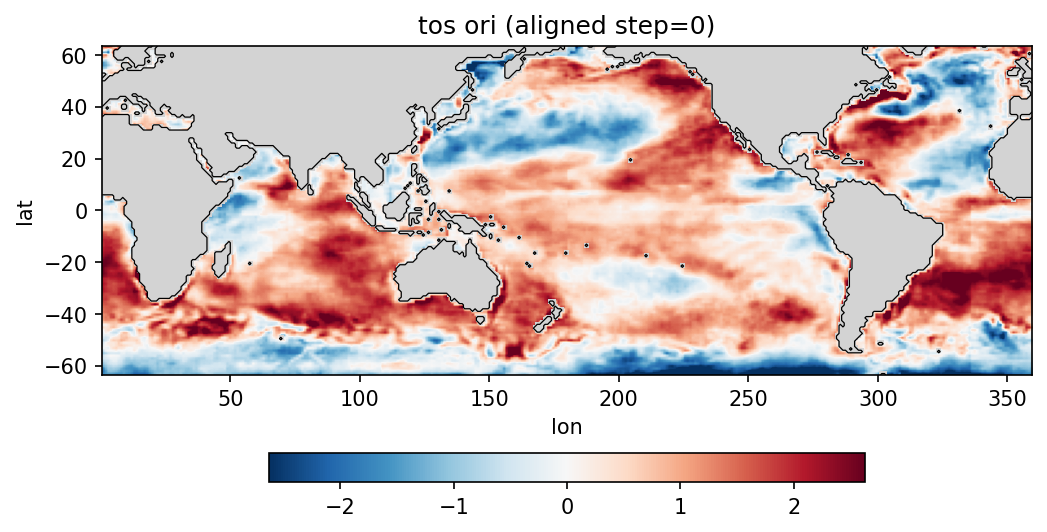

Saved tos map to /mnt/data/zhu.yishun/ORCA-DL-main/tos_ori.png


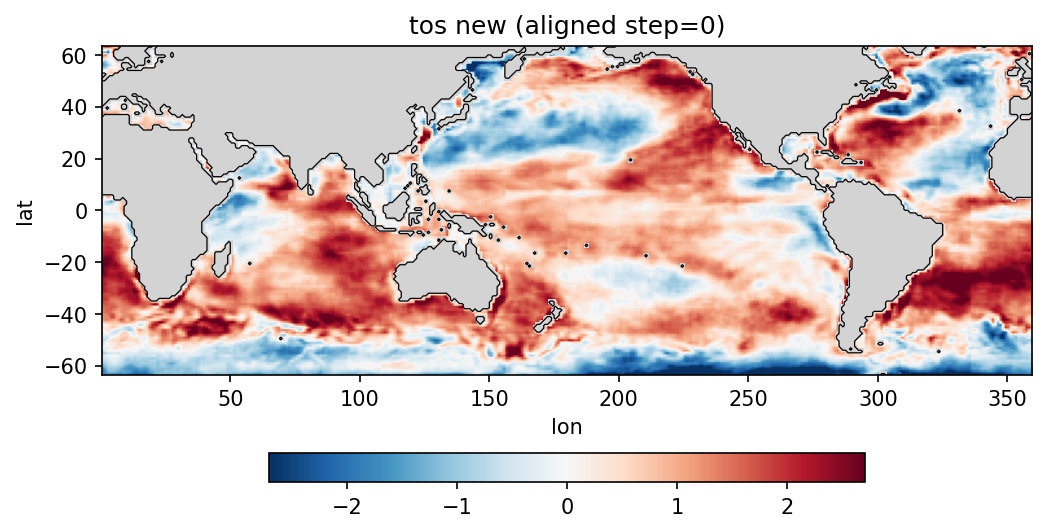

Saved tos map to /mnt/data/zhu.yishun/ORCA-DL-main/tos_new.png


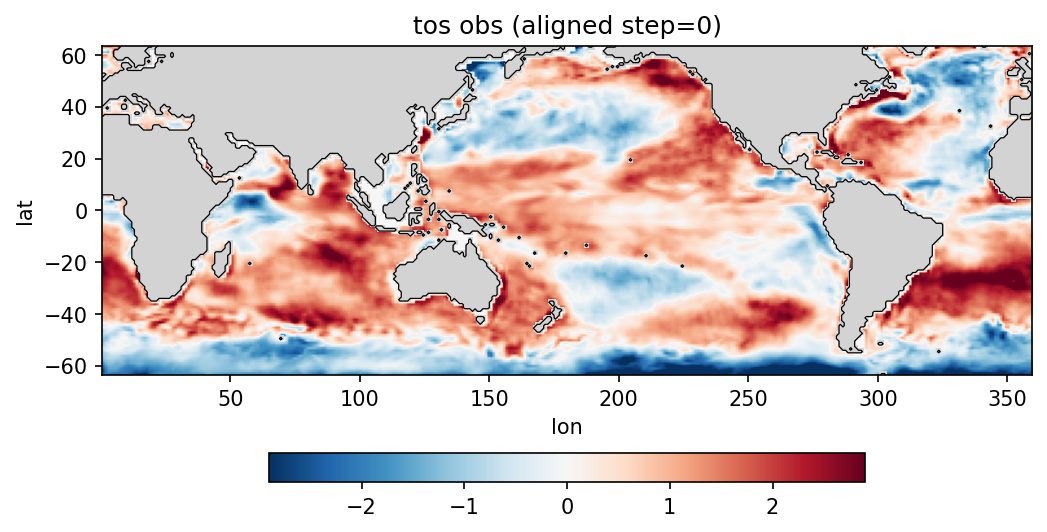

Saved tos map to /mnt/data/zhu.yishun/ORCA-DL-main/tos_obs.png


In [54]:
# 计算海表温度(tos)并分别保存 ori/new/obs 三张图（不再画差分）
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def get_tos_field(preds, predictor, step=0, sample=0):
    arr = np.array(preds)
    if arr.ndim == 5:
        data = arr
    elif arr.ndim == 4:
        data = arr[:, None, ...]
    elif arr.ndim == 3:
        data = arr[None, None, ...]
    else:
        raise ValueError(f'Unsupported preds ndim: {arr.ndim}')
    # locate tos channels
    i = predictor.MODEL_OCEAN_VARIABLES.index('tos')
    start_ch = 0 if i == 0 else predictor.split_chans[i-1]
    end_ch = predictor.split_chans[i]
    # clamp step/sample
    step = int(min(max(0, step), data.shape[1]-1))
    sample = int(min(max(0, sample), data.shape[0]-1))
    field = data[sample, step, start_ch:end_ch, :, :]
    if field.shape[0] > 1:
        field = np.nanmean(field, axis=0)
    else:
        field = field[0]
    return field

def match_shape(a, target_shape):
    a = np.array(a)
    if a.shape == target_shape:
        return a
    try:
        from scipy.ndimage import zoom
        zy = target_shape[0] / a.shape[0]
        zx = target_shape[1] / a.shape[1]
        return zoom(a, (zy, zx), order=1)
    except Exception:
        out = np.zeros(target_shape)
        h = min(a.shape[0], target_shape[0])
        w = min(a.shape[1], target_shape[1])
        out[:h,:w] = a[:h,:w]
        return out

# 获取观测 tos（优先使用 notebook 中的 ocean_data，否则从 data_dir 读取对应文件）
obs_tos = None
obs_raw = None

# 如果还未找到，从 data_dir 中读取对应月份的文件（data_dir 需在 notebook 中定义）
if obs_tos is None:
    data_dir = globals().get('data_dir', '/mnt/data/zhu.yishun/ORCA-DL-main/data/valid_test_data/GODAS')
    year = globals().get('year', None)
    month = globals().get('start_month', globals().get('month', None))
    if year is not None and month is not None:
        try:
            mval = int(month)
            if 0 <= mval <= 11:
                month_val = mval + 1
            else:
                month_val = mval
        except Exception:
            month_val = month
        for name in ('tos', 'sst'):
            fpath = os.path.join(data_dir, name, f"{year}_{month_val}.npy")
            if os.path.exists(fpath):
                try:
                    arr = np.load(fpath)
                    obs_raw = arr
                    if arr.ndim == 3:
                        obs_tos = arr[-1] if arr.shape[0] > 1 else arr[0]
                    elif arr.ndim == 2:
                        obs_tos = arr
                    break
                except Exception as e:
                    print('读取观测文件失败', fpath, e)
    if obs_tos is None:
        print('观测 tos 未找到；请确保 ocean_data 中含 tos 或 data_dir 下有对应文件')

# 提取预测 tos（根据观测时间对齐 step，如果无法对齐使用 step=0）
pred_ori_tos = None
pred_new_tos = None
# 期望的时间索引（以整数步计，优先使用 start_month/month），默认0
desired_idx = globals().get('start_month', globals().get('month', 0))
try:
    desired_idx = int(desired_idx)
except Exception:
    desired_idx = 0
    print('无法解析 desired_idx，使用 0')
# If obs_raw has time dimension, try to align desired_idx to its length
if obs_raw is not None and getattr(obs_raw, 'ndim', 0) == 3:
    if desired_idx < 0:
        desired_idx = obs_raw.shape[0]-1
    desired_idx = min(desired_idx, obs_raw.shape[0]-1)
# 提取并用 desired_idx 作为模型 step（如果模型没有那么多步，会自动 clamp）
if 'result_ori' in globals() and result_ori is not None:
    try:
        pred_ori_tos = get_tos_field(result_ori.predictions, predictor_ori if 'predictor_ori' in globals() else predictor_new, step=desired_idx, sample=0)
    except Exception as e:
        print('提取 result_ori 失败:', e)
if 'result_new' in globals() and result_new is not None:
    try:
        pred_new_tos = get_tos_field(result_new.predictions, predictor_new if 'predictor_new' in globals() else predictor_ori, step=desired_idx, sample=0)
    except Exception as e:
        print('提取 result_new 失败:', e)

if obs_tos is None and (pred_ori_tos is None and pred_new_tos is None):
    print('没有足够的数据进行绘图')
else:
    # 配准形状（如需）
    H,W = obs_tos.shape if obs_tos is not None else (None,None)
    if pred_ori_tos is not None and H is not None and pred_ori_tos.shape != (H,W):
        pred_ori_tos = match_shape(pred_ori_tos, (H,W))
    if pred_new_tos is not None and H is not None and pred_new_tos.shape != (H,W):
        pred_new_tos = match_shape(pred_new_tos, (H,W))
    # 获取经纬度范围（尝试使用 predictor.config 配置）
    extent = None
    try:
        cfg = predictor_new.config if 'predictor_new' in globals() and predictor_new is not None else (predictor_ori.config if 'predictor_ori' in globals() and predictor_ori is not None else None)
        if cfg is not None:
            lat0, lat1, nlat = cfg.lat_space
            lon0, lon1, nlon = cfg.lon_space
            extent = [lon0, lon1, lat0, lat1]
    except Exception:
        extent = None
    # 获取陆地掩码（优先使用之前计算好的 stat_nan_masks，否则由观测 NaN 推断）
    land_mask = None
    try:
        if 'stat_nan_masks' in globals() and 'tos' in stat_nan_masks:
            land_mask = stat_nan_masks['tos']
            # 确保是布尔型
            land_mask = np.array(land_mask, dtype=bool)
    except Exception:
        land_mask = None
    if land_mask is None and obs_tos is not None:
        land_mask = np.isnan(obs_tos)
    # 如果掩码形状与场形状不一致，尝试配准后对每张图进行处理并保存
    fields = []
    if pred_ori_tos is not None:
        fields.append(('ori', pred_ori_tos))
    if pred_new_tos is not None:
        fields.append(('new', pred_new_tos))
    if obs_tos is not None:
        fields.append(('obs', obs_tos))
    saved = []
    for tag, field in fields:
        d = np.array(field, dtype=float)
        m = None
        if land_mask is not None:
            try:
                if land_mask.shape != d.shape:
                    m = match_shape(np.array(land_mask, dtype=float), d.shape) > 0.5
                else:
                    m = np.array(land_mask, dtype=bool)
                d[m] = np.nan
            except Exception:
                m = None
        vals = np.abs(d[~np.isnan(d)]) if np.any(~np.isnan(d)) else np.array([])
        if vals.size:
            vmax = float(np.nanpercentile(vals, 98))
            if vmax <= 0:
                vmax = float(np.nanmax(vals)) if vals.size else 1e-6
        else:
            vmax = 1e-6
        cmap = plt.get_cmap('RdBu_r')
        try:
            cmap.set_bad('lightgray')
        except Exception:
            pass
        fig, ax = plt.subplots(figsize=(8,6))
        if extent is not None:
            im = ax.imshow(d, origin='lower', cmap=cmap, vmin=-vmax, vmax=vmax, extent=extent)
        else:
            im = ax.imshow(d, origin='lower', cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(f'tos {tag} (aligned step={desired_idx})')
        ax.set_xlabel('lon')
        ax.set_ylabel('lat')
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.046, pad=0.12)
        fig.subplots_adjust(bottom=0.16)
        if m is not None:
            try:
                mask_plot = np.array(m, dtype=float)
                if extent is not None:
                    lon = np.linspace(extent[0], extent[1], d.shape[1])
                    lat = np.linspace(extent[2], extent[3], d.shape[0])
                    Lon, Lat = np.meshgrid(lon, lat)
                    ax.contour(Lon, Lat, mask_plot, levels=[0.5], colors='k', linewidths=0.6)
                else:
                    ax.contour(mask_plot, levels=[0.5], colors='k', linewidths=0.6, origin='lower')
            except Exception:
                pass
        out_png = f'/mnt/data/zhu.yishun/ORCA-DL-main/tos_{tag}.png'
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.close(fig)
        try:
            display(Image(out_png))
        except Exception:
            print('已保存图片到', out_png)
        print('Saved tos map to', out_png)
        saved.append(out_png)
    if not saved:
        print('没有生成任何海表温度图')


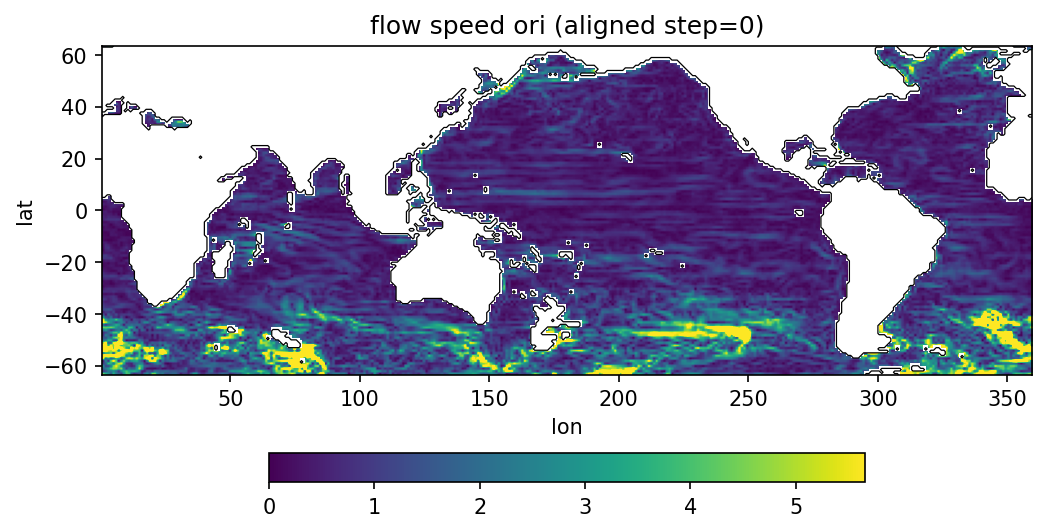

Saved flow speed to /mnt/data/zhu.yishun/ORCA-DL-main/flow_speed_ori.png


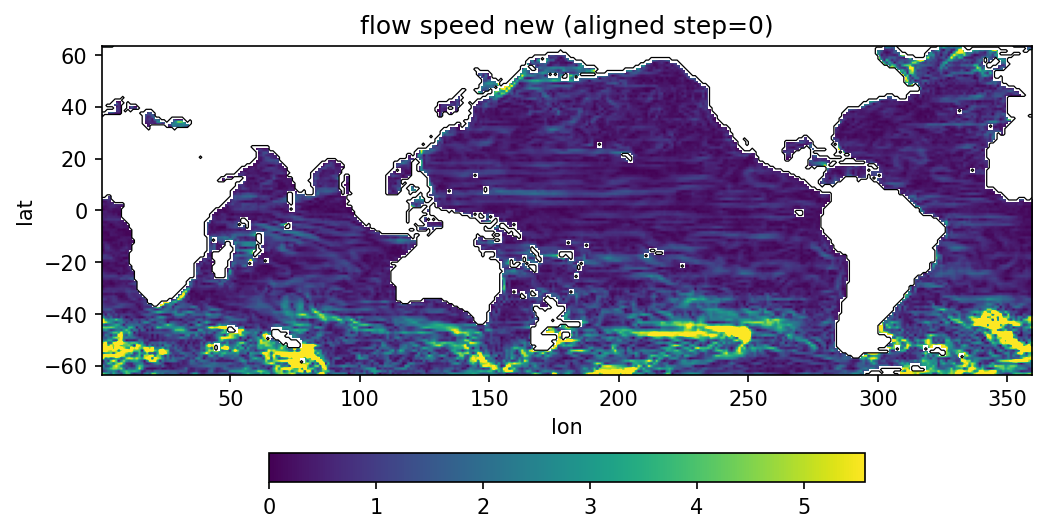

Saved flow speed to /mnt/data/zhu.yishun/ORCA-DL-main/flow_speed_new.png


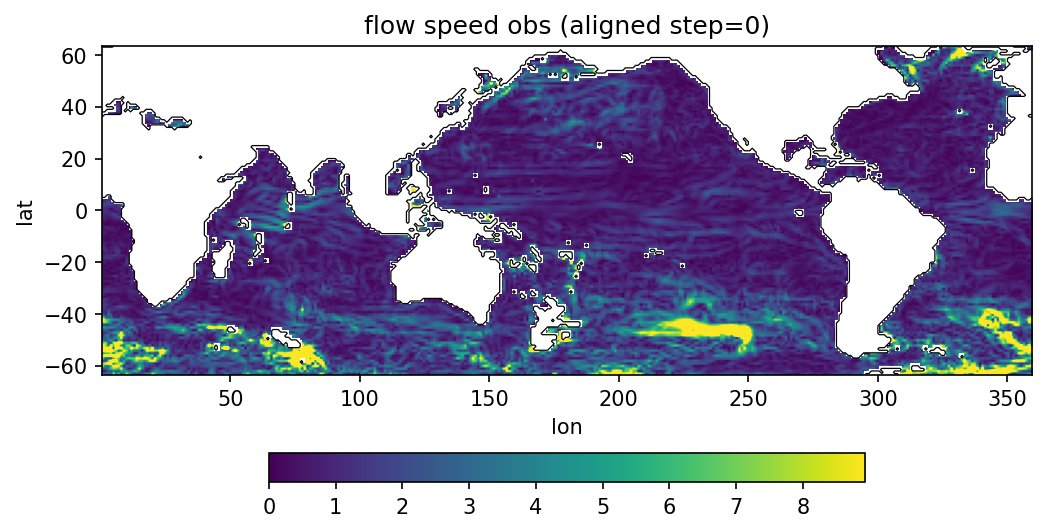

Saved flow speed to /mnt/data/zhu.yishun/ORCA-DL-main/flow_speed_obs.png


In [55]:
# 绘制预测与观测的流速（分别保存 ori/new/obs），不再绘制 bias
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def get_field(preds, predictor, varname, step=0, sample=0):
    arr = np.array(preds)
    if arr.ndim == 5:
        data = arr
    elif arr.ndim == 4:
        data = arr[:, None, ...]
    elif arr.ndim == 3:
        data = arr[None, None, ...]
    else:
        raise ValueError(f'Unsupported preds ndim: {arr.ndim}')
    i = predictor.MODEL_OCEAN_VARIABLES.index(varname)
    start_ch = 0 if i == 0 else predictor.split_chans[i-1]
    end_ch = predictor.split_chans[i]
    step = int(min(max(0, int(step)), data.shape[1]-1))
    sample = int(min(max(0, int(sample)), data.shape[0]-1))
    field = data[sample, step, start_ch:end_ch, :, :]
    if field.shape[0] > 1:
        field = np.nanmean(field, axis=0)
    else:
        field = field[0]
    return field

def match_shape(a, target_shape):
    a = np.array(a)
    if a.shape == target_shape:
        return a
    try:
        from scipy.ndimage import zoom
        zy = target_shape[0] / a.shape[0]
        zx = target_shape[1] / a.shape[1]
        return zoom(a, (zy, zx), order=1)
    except Exception:
        out = np.zeros(target_shape)
        h = min(a.shape[0], target_shape[0])
        w = min(a.shape[1], target_shape[1])
        out[:h,:w] = a[:h,:w]
        return out

# 时间索引（与 tos 单元一致）
desired_idx = globals().get('start_month', globals().get('month', 0))
try:
    desired_idx = int(desired_idx)
except Exception:
    desired_idx = 0

# 提取观测 uo/vo（优先 ocean_data，否则尝试从 data_dir 读取）
obs_u = ocean_data.get('uo') if 'ocean_data' in globals() else None
obs_v = ocean_data.get('vo') if 'ocean_data' in globals() else None

def extract_obs_component(arr, idx):
    if arr is None:
        return None, None
    a = np.array(arr)
    if a.ndim == 3:
        idx = max(0, min(idx, a.shape[0]-1))
        return a[idx], a
    if a.ndim == 2:
        return a, a
    return None, a

obs_u_field, obs_raw_u = extract_obs_component(obs_u, desired_idx)
obs_v_field, obs_raw_v = extract_obs_component(obs_v, desired_idx)

if obs_u_field is None or obs_v_field is None:
    data_dir = globals().get('data_dir', '/mnt/data/zhu.yishun/ORCA-DL-main/data/valid_test_data/GODAS')
    year = globals().get('year', None)
    month = globals().get('start_month', globals().get('month', None))
    if year is not None and month is not None:
        try:
            mval = int(month)
            month_val = mval+1 if 0 <= mval <= 11 else mval
        except Exception:
            month_val = month
        for name in ('uo','vo'):
            fpath = os.path.join(data_dir, name, f"{year}_{month_val}.npy")
            if os.path.exists(fpath):
                try:
                    arr = np.load(fpath)
                    if name == 'uo' and obs_u_field is None:
                        obs_u_field = arr[-1] if getattr(arr,'ndim',0)==3 and arr.shape[0]>1 else (arr if getattr(arr,'ndim',0)==2 else None)
                    if name == 'vo' and obs_v_field is None:
                        obs_v_field = arr[-1] if getattr(arr,'ndim',0)==3 and arr.shape[0]>1 else (arr if getattr(arr,'ndim',0)==2 else None)
                except Exception:
                    pass

# 计算观测流速（若可用）
obs_speed = None
if obs_u_field is not None and obs_v_field is not None:
    try:
        obs_speed = np.sqrt(np.array(obs_u_field, dtype=float)**2 + np.array(obs_v_field, dtype=float)**2)
    except Exception as e:
        print('计算观测流速失败:', e)

# 提取预测分量并计算速度
pred_ori_speed = None
pred_new_speed = None
if 'result_ori' in globals() and result_ori is not None and 'predictor_ori' in globals() and predictor_ori is not None:
    try:
        uo_o = get_field(result_ori.predictions, predictor_ori, 'uo', step=desired_idx, sample=0)
        vo_o = get_field(result_ori.predictions, predictor_ori, 'vo', step=desired_idx, sample=0)
        pred_ori_speed = np.sqrt(uo_o**2 + vo_o**2)
    except Exception as e:
        print('提取 pred_ori 流速失败:', e)
if 'result_new' in globals() and result_new is not None and 'predictor_new' in globals() and predictor_new is not None:
    try:
        uo_n = get_field(result_new.predictions, predictor_new, 'uo', step=desired_idx, sample=0)
        vo_n = get_field(result_new.predictions, predictor_new, 'vo', step=desired_idx, sample=0)
        pred_new_speed = np.sqrt(uo_n**2 + vo_n**2)
    except Exception as e:
        print('提取 pred_new 流速失败:', e)

# 准备单独绘图列表
fields = []
if pred_ori_speed is not None:
    fields.append(('ori', pred_ori_speed))
if pred_new_speed is not None:
    fields.append(('new', pred_new_speed))
if obs_speed is not None:
    fields.append(('obs', obs_speed))

if not fields:
    print('没有足够的数据绘制流速场（需要观测或预测）')
else:
    # 获取 extent 与 land_mask（复用 tos 单元逻辑）
    extent = None
    try:
        cfg = predictor_new.config if 'predictor_new' in globals() and predictor_new is not None else (predictor_ori.config if 'predictor_ori' in globals() and predictor_ori is not None else None)
        if cfg is not None:
            lat0, lat1, nlat = cfg.lat_space
            lon0, lon1, nlon = cfg.lon_space
            extent = [lon0, lon1, lat0, lat1]
    except Exception:
        extent = None
    land_mask = None
    try:
        if 'stat_nan_masks' in globals() and 'uo' in stat_nan_masks:
            land_mask = stat_nan_masks['uo']
        elif 'stat_nan_masks' in globals() and 'tos' in stat_nan_masks:
            land_mask = stat_nan_masks['tos']
        if land_mask is not None:
            land_mask = np.array(land_mask, dtype=bool)
    except Exception:
        land_mask = None
    # 保存每张速度图
    saved = []
    for tag, f in fields:
        d = np.array(f, dtype=float)
        m = None
        if land_mask is not None:
            try:
                if land_mask.shape != d.shape:
                    m = match_shape(np.array(land_mask, dtype=float), d.shape) > 0.5
                else:
                    m = np.array(land_mask, dtype=bool)
                d[m] = np.nan
            except Exception:
                m = None
        vals = d[~np.isnan(d)] if np.any(~np.isnan(d)) else np.array([])
        if vals.size:
            vmax = float(np.nanpercentile(vals, 98))
            if vmax <= 0:
                vmax = float(np.nanmax(vals)) if vals.size else 1e-6
        else:
            vmax = 1e-6
        cmap = plt.get_cmap('viridis')
        fig, ax = plt.subplots(figsize=(8,6))
        if extent is not None:
            im = ax.imshow(d, origin='lower', cmap=cmap, vmin=0, vmax=vmax, extent=extent)
        else:
            im = ax.imshow(d, origin='lower', cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(f'flow speed {tag} (aligned step={desired_idx})')
        ax.set_xlabel('lon')
        ax.set_ylabel('lat')
        cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.046, pad=0.12)
        fig.subplots_adjust(bottom=0.16)
        if m is not None:
            try:
                mask_plot = np.array(m, dtype=float)
                if extent is not None:
                    lon = np.linspace(extent[0], extent[1], d.shape[1])
                    lat = np.linspace(extent[2], extent[3], d.shape[0])
                    Lon, Lat = np.meshgrid(lon, lat)
                    ax.contour(Lon, Lat, mask_plot, levels=[0.5], colors='k', linewidths=0.6)
                else:
                    ax.contour(mask_plot, levels=[0.5], colors='k', linewidths=0.6, origin='lower')
            except Exception:
                pass
        out_png = f'/mnt/data/zhu.yishun/ORCA-DL-main/flow_speed_{tag}.png'
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.close(fig)
        try:
            display(Image(out_png))
        except Exception:
            print('已保存图片到', out_png)
        print('Saved flow speed to', out_png)
        saved.append(out_png)
    if not saved:
        print('未生成流速图')


In [8]:
# 计算 tos 在 1993-2023 年每个日历月的第90百分位（注意：data_dir 中是已标准化数据，需要反标准化后计算）
import os
import numpy as np

# 完整网格范围与点数（用于检查）
LAT_MIN, LAT_MAX, LAT_POINTS = -63.5, 63.5, 128
LON_MIN, LON_MAX, LON_POINTS = 0.5, 359.5, 360

data_dir = '/mnt/data/zhu.yishun/ORCA-DL-main/data/valid_test_data/GODAS/tos'
years = range(1993, 2024)
# stat 目录（mean/std），data_dir 中的数据被 (x-mean)/std 标准化
STAT_ROOT = '/mnt/data/zhu.yishun/ORCA-DL-main/stat'
MEAN_DIR = os.path.join(STAT_ROOT, 'mean')
STD_DIR = os.path.join(STAT_ROOT, 'std')

# 决定 stat 文件名：优先使用 predictor_new 的映射，其次尝试 'tos' 和 'sst'（stat 目录里有 sst.npy）
stat_name = None
try:
    if 'predictor_new' in globals() and predictor_new is not None:
        cand = predictor_new._get_stat_var_name('tos')
        stat_name = cand if cand else None
except Exception:
    stat_name = None
# 候选列表，按优先级检查文件存在性
candidates = [stat_name, 'tos', 'sst']
found = None
for c in candidates:
    if not c:
        continue
    mpath = os.path.join(MEAN_DIR, f"{c}.npy")
    spath = os.path.join(STD_DIR, f"{c}.npy")
    if os.path.exists(mpath) and os.path.exists(spath):
        found = c
        break
print('Using stat name:', found)
if found is None:
    raise FileNotFoundError(f"Missing stat files for candidates {candidates} in {MEAN_DIR} / {STD_DIR}")
stat_name = found
mean_path = os.path.join(MEAN_DIR, f"{stat_name}.npy")
std_path = os.path.join(STD_DIR, f"{stat_name}.npy")
mean = np.load(mean_path)
std  = np.load(std_path)
print('Loaded mean/std shapes:', mean.shape, std.shape)
# 如果 stat 是按月保存的 (12, H, W)，则为 monthly_stats；否则将 mean/std 降维到 (H,W)
monthly_stats = False
if mean.ndim == 3 and mean.shape[0] == 12 and std.ndim == 3 and std.shape[0] == 12:
    monthly_stats = True
    target_shape = (mean.shape[1], mean.shape[2])
else:
    if mean.ndim > 2:
        reduce_axes = tuple(range(mean.ndim - 2))
        mean = np.mean(mean, axis=reduce_axes)
    if std.ndim > 2:
        reduce_axes = tuple(range(std.ndim - 2))
        std = np.mean(std, axis=reduce_axes)
    target_shape = mean.shape

# 工具：把文件数组转换为2D场并对齐到 mean/std 的形状（尝试 transpose 或缩放）
def to_2d_field(a):
    a = np.array(a, dtype=float)
    if a.ndim == 2:
        return a
    if a.ndim == 3:
        if a.shape[0] == 1:
            return a[0]
        else:
            return a[-1]
    arr = np.squeeze(a)
    if arr.ndim == 2:
        return arr
    raise ValueError('不支持的数组维度: ' + str(a.shape))

def align_to_target(field, target_shape):
    if field.shape == target_shape:
        return field
    # 尝试转置情形
    if field.T.shape == target_shape:
        return field.T
    # 尝试使用 scipy.ndimage.zoom 进行缩放对齐（若不可用则进行裁切/填充）
    try:
        from scipy.ndimage import zoom
        zy = target_shape[0] / field.shape[0]
        zx = target_shape[1] / field.shape[1]
        return zoom(field, (zy, zx), order=1)
    except Exception:
        out = np.full(target_shape, np.nan, dtype=float)
        h = min(field.shape[0], target_shape[0])
        w = min(field.shape[1], target_shape[1])
        out[:h, :w] = field[:h, :w]
        return out

# 读取并对每月做反标准化后收集
months_data = [[] for _ in range(12)]
missing = []
# 确保 target_shape 已由上文设置（按月或全局）
if 'target_shape' not in globals():
    target_shape = mean.shape if not ('monthly_stats' in globals() and monthly_stats) else (mean.shape[1], mean.shape[2])
for y in years:
    for m in range(1, 13):
        fname = f"{y}_{m}.npy"
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            missing.append(fpath)
            continue
        try:
            a = np.load(fpath)
        except Exception as e:
            print('无法加载', fpath, e)
            missing.append(fpath)
            continue
        try:
            field = to_2d_field(a)
        except Exception as e:
            print('跳过不支持的数组形状:', fpath, getattr(a, 'shape', None), e)
            missing.append(fpath)
            continue
        # 对齐到 stat 的空间网格
        field_aligned = align_to_target(field, target_shape)
        # 按月或按全局选择 mean/std 并反标准化： actual = normalized * std + mean
        if 'monthly_stats' in globals() and monthly_stats:
            mean_m = mean[m-1]
            std_m = std[m-1]
        else:
            mean_m = mean
            std_m = std
        unscaled = field_aligned * std_m + mean_m
        # 对于 mean/std 为 NaN 的位置，保留 NaN
        nan_mask = np.isnan(mean_m) | np.isnan(std_m)
        if np.any(nan_mask):
            unscaled[nan_mask] = np.nan
        months_data[m-1].append(unscaled)

# 逐月计算第90百分位，结果为 (12, H, W)
p90_months = []
for i in range(12):
    arrs = months_data[i]
    if not arrs:
        p90 = np.full(target_shape, np.nan)
    else:
        stack = np.stack(arrs, axis=0)  # (N_years, H, W)
        p90 = np.nanpercentile(stack, 90, axis=0)
    # 修正可能的维度顺序 (防止 lon/lat 颠倒)
    if p90.shape == (LON_POINTS, LAT_POINTS):
        p90 = p90.T
    if p90.shape != (LAT_POINTS, LON_POINTS):
        print('警告：第{}月输出 shape 与期望不符:'.format(i+1), p90.shape, '期望:', (LAT_POINTS, LON_POINTS))
    p90_months.append(p90)

p90_months = np.stack(p90_months, axis=0)  # (12, H, W)
print('p90_months shape:', p90_months.shape)
if missing:
    print('警告：部分文件缺失，示例路径(最多5):', missing[:5])

out_path = '/mnt/data/zhu.yishun/ORCA-DL-main/tos_p90_monthly_1993_2023.npy'
np.save(out_path, p90_months)
print('已保存每月第90百分位到:', out_path)

Using stat name: sst
Loaded mean/std shapes: (12, 128, 360) (12, 128, 360)


p90_months shape: (12, 128, 360)
已保存每月第90百分位到: /mnt/data/zhu.yishun/ORCA-DL-main/tos_p90_monthly_1993_2023.npy


In [9]:
print(p90)

[[-0.84815413 -0.80950266 -0.76129349 ... -0.67787024 -0.73539064
  -0.81769552]
 [-0.9298235  -0.91556642 -0.88017661 ... -0.79495857 -0.74641719
  -0.83174939]
 [-0.89680747 -0.91255118 -0.8864932  ... -0.81058089 -0.70163749
  -0.75948619]
 ...
 [-0.93998363 -0.93935878 -1.32892528 ...  1.58319327 -0.18396879
  -0.81016184]
 [ 0.17089962 -0.17173777 -0.54558911 ...  1.46016085  0.99333186
   0.65749775]
 [ 0.78490493  0.81454372  0.85261304 ...  1.28763828  1.04753268
   0.87805658]]


In [9]:
print(p90)

[[0.54136277 0.56424728 0.61306844 ... 0.40709679 0.46507762 0.52000486]
 [0.30181047 0.28044438 0.26823274 ... 0.23465847 0.30030009 0.31860813]
 [0.21329598 0.15073676 0.13241895 ... 0.23469007 0.30183655 0.27741886]
 ...
 [8.92334946 8.82959057 8.69679691 ... 9.12886668 8.99579397 8.97608769]
 [8.28508982 8.43626313 8.57680556 ... 8.18865427 8.14604186 8.26651448]
 [7.93589567 8.17237512 8.36008411 ... 7.50700566 7.60458926 7.74818533]]


In [ ]:
import numpy as np
import os
npy_path = '/mnt/data/zhu.yishun/ORCA-DL-main/data/godas2025-12/pottmp.npy'

if not os.path.exists(npy_path):
    print("文件不存在:", npy_path)
else:
    arr = np.load(npy_path, allow_pickle=True)
    print("文件路径:", npy_path)
    print("类型:", type(arr))
    print("dtype:", getattr(arr, "dtype", None))
    print("ndim:", getattr(arr, "ndim", None))
    print("shape:", getattr(arr, "shape", None))
    if isinstance(arr, np.ndarray):
        print("min:", np.nanmin(arr))
        print("max:", np.nanmax(arr))
        print("nan count:", np.isnan(arr).sum())
        if arr.size <= 20:
            print("内容预览:", arr)
        else:
            print("内容预览(前10):", arr.ravel()[:10])
    else:
        print("非 ndarray 内容预览:", arr)

文件路径: /mnt/data/zhu.yishun/ORCA-DL-main/data/godas2025-12/pottmp.npy
类型: <class 'numpy.ndarray'>
dtype: float32
ndim: 3
shape: (16, 128, 360)
min: -757.37085
max: 209.68922
nan count: 228400
内容预览(前10): [-1.5996674 -1.6063548 -1.5870045 -1.5920603 -1.6319758 -1.7334131
 -1.9273772 -2.0856414 -2.1599636 -2.1764276]


In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime

def npy_to_nc(npy_path, nc_path,
              var_name='pottmp', units='degC',
              time_coords=None, lat_coords=None, lon_coords=None,
              time_start=None, time_freq=None,
              fill_value=-9999.0, compress=True):
    data = np.load(npy_path)  # expect (time, lat, lon)
    if data.ndim != 3:
        raise ValueError("Expect a 3D array (time, lat, lon)")

    nt, nlat, nlon = data.shape

    # time coordinates
    if time_coords is not None:
        time = pd.to_datetime(time_coords)
    elif time_start is not None and time_freq is not None:
        time = pd.date_range(start=time_start, periods=nt, freq=time_freq)
    else:
        # fallback: integer index starting at 0
        time = np.arange(nt)

    # lon coordinates (0..360) default
    if lon_coords is not None:
        lon = np.asarray(lon_coords)
    else:
        lon = np.linspace(0, 360, nlon, endpoint=False)

    # lat coordinates (centered) default: from 90 to -90
    if lat_coords is not None:
        lat = np.asarray(lat_coords)
    else:
        # place centers evenly between 90 and -90
        lat = np.linspace(90 - 180/nlat/2, -90 + 180/nlat/2, nlat)

    da = xr.DataArray(
        data.astype('float32'),
        dims=('time', 'lat', 'lon'),
        coords={'time': time, 'lat': lat, 'lon': lon},
        name=var_name
    )

    da.attrs['units'] = units
    da.attrs['long_name'] = var_name

    ds = da.to_dataset()

    encoding = {var_name: {'_FillValue': np.float32(fill_value),
                           'dtype': 'float32'}}
    if compress:
        encoding[var_name].update({'zlib': True, 'complevel': 4})

    ds.to_netcdf(nc_path, encoding=encoding)
    return nc_path

# 示例用法（默认会创建规则经纬网和整数时间索引）
if __name__ == "__main__":
    npy_path = "/mnt/data/zhu.yishun/ORCA-DL-main/data/godas2025-12/pottmp.npy"
    nc_path = "/mnt/data/zhu.yishun/ORCA-DL-main/data/godas2025-12/pottmp.nc"
    # 若你知道时间起点和频率，例如从 2025-01-01 每月一次:
    # npy_to_nc(npy_path, nc_path, time_start="2025-01-01", time_freq="MS")
    npy_to_nc(npy_path, nc_path)